<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/LLM_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description

Building a Large Language Model for text generation from scratch

**ML Algorithm**:  Generative Pre-trained Transformer <br>
**Dataset**: Edith Wharton's "The Verdict (1908)" (Adapted for the computational limitations of MacBook Air) <br>
**Framework**: PyTorch

# Dataloader


### Tokenization
[BPE tokenizer](https://github.com/openai/tiktoken) was used to train LLMs such as GPT-2 (Generative Pre-trained Transformer) <br>

**Vocabulary** defines how we map each unique word/char and special character to a unique integer. <br>

In [RNN](https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/RNN_scratch_pytorch.ipynb?authuser=1#scrollTo=CwXI-m9xTMFD), we used ***character embedding*** wrt ***frequency*** of the character within that text. <br> For Transformers, we will use ***word embedding*** and token id's would be given to words as per the ***BPE tokenizer***. <br>

The algorithm underlying BPE breaks down words that aren’t in its predefined vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words.



In [84]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Inherit the PyTorch Dataset(modify as per the text inputs for GPT: Generative Pre-trained Transformer)

class GPTDataset(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    super().__init__()
    self.input_ids = []   # 2D List (N * max_length): (3, 2) [[This, is],[an, example],[to, visulaize]]
    self.target_ids = []  # 2D List (N * max_length): (3, 2) [[is, an], [example, to], [visualize, end]]; For next word prediction, shifted by 1

    # Tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special = {'<|endoftext|>'}) # List of integers: Each word gets one or multiple integer assigned

    # Use Sliding Window technique: use stride=max_length to avoid overlap in input text

    for i in range(0, len(token_ids)-max_length, stride):
      input = token_ids[i:i+max_length]            # 1D List of integers(max_length): max_length is context vector length
      target = token_ids[i+1:i+max_length+1]       # 1D List of integers(max_length): Next word prediction, target (label) is shifted by 1 wrt input
      self.input_ids.append(torch.tensor(input))   # Convert to Torch Tensor, to meet the dataset input expected per the NN layers
      self.target_ids.append(torch.tensor(target))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]   # (x,y): (Input, Label) of a general dataset

def create_dataloader(txt, max_length=256, stride=128, batch_size=4, shuffle=True, drop_last=True, num_workers=0):

  # Initialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDataset(txt, tokenizer, max_length, stride)   # Expects the dataset as Torch tensors of (Input, Label)

  # Create dataloader: Original PyTorch iterator
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)  # 2D List: Input: [batch_size, max_length], each row shifted by stride; Target: [batch_size, max_length]

  return dataloader


### Word embedding

* Word embedding can be considered as a look up vector for each token id.
* Since LLMs are like Deep Neural Networks, it needs weight matrices to be trained via Backpropagation.
* The weight matrix of the embedding layer contains small, random values, which are optimized during LLM training, similar to how weights are trained for general DNNs.

#### Token Embedding Layer:
**Input**: Vocab size (Set of token IDs from text, non-repeating) <br>
**Output**: Embedding Dimension (1 word/token_id corresponds to a look up vector of the stated vector size)

#### Position Embedding Layer:
Positional embeddings can be used to consider where the word has been used in the sentence. The same word "the" at the beginning of the sentence or towards the end of the sentence might expect different target words.

* Relative: Order of input context vector and within one input context vector relative placement of one word wrt another `[[1.1, 1.2, 1.3],[2.1, 2.2, 2.3]]`
* Absolute: Just within one input context vector relative placement of one word wrt another `[[1,2,3],[1,2,3]]`
  * GPT-2 considers Absolute.
  * Also note that we are shuffling the batches of data, so Relative positional embedding, might mess up the weights in case of smaller batch values.

**Input**: Input Context Vector size <br>
**Output**: Same as the Output Embedding dimension <br>

**Embedding** = Token Embedding + Position Embedding


# Multi-head Attention Mechanism

This is "THE" vital concept that differentiates a Transformer model from the older Neural Network models like RNN, that was being used for text translation/ generation in the earlier days (often incorrectly), until this paper came out: [Attention Is All You Need](https://arxiv.org/abs/1706.03762), and marked the Inception of Large Language Models!! 🥁🥁

### Self-Attention Mechanism
Self-Attention mechanism assesses and learns the relationships and dependencies between various parts of the input itself, such as words in a sentence or pixels in an image. <br>
In self-attention:
  * Introduce 3 Weight Matrices: $W_q, W_k, W_v$
  * Project the embedded input tokens $x^{(i)}$, into query, key, and value vectors:
    * Query vector: $q^{(i)} = x^{(i)}.W_q$
    * Key vector: $k^{(i)} = x^{(i)}.W_k$
    * Value vector: $v^{(i)} = x^{(i)}.W_v$
  * Compute Attention scores as dot products between the query and each key vector:
    * $ω^{(i)} = q^{(i)}.k^{T}$
    * One embedding vector wrt every other embedding vector, Attention scores is a matrix of size (Context_length, Context_length)
    * If Context Length is 3: $ω^{(1)} = w_{11}, w_{12}, w_{13}$
  * Compute Attention weights by normalizing scaled attention scores using softmax
    * If Context Length is 3: $a^{(1)} = a_{11}, a_{12}, a_{13}$, size remains as attention scores.
  * Compute Context Vectors as weighted sum over the inputs:
    * $z^{(i)} = a^{(i)}.v$
    * Every input token embedding vector $x^{(i)}$ will have a corresponding context vector $z^{(i)}$. The dimension of each context vector depends on design. Overall, $z$ is (Context_length, out_dim by system design)
  * Use PyTorch `nn.Linear` without the bias, it acts just like matrix multiplication, and allows the weights to learn through model training

**Casual Self-Attention**

It ensures that each next word prediction should only depend on the preceding words by masking out the future tokens.

**Dropout**

This helps in the overfitting problem: Using a dropout rate like 50%, would randomly mask out half of the attention weights and then scale the non-dropped out attention weights with: 1 / (1 - dropout_rate)

### Multi-head attention mechanism

And then people thought, what if we repeat this for multiple weights for Queries, Keys and Values and that's how kids- How they met multi-head attention (No pun intended) 😎

* Stack multiple single-head attention modules (in parallel)  with different, learned linear projections
* This allows the model to jointly attend to information from different representation subspaces at different positions.

In [85]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out should be divisible by num_heads"

    self.num_heads = num_heads
    self.d_out = d_out                               # d_out is the final dimension of output context vector, which we will split amongst num_heads
    self.head_dims = d_out // num_heads

    ## Weight Matrices
    self.W_q = nn.Linear(d_in, d_out, bias=qkv_bias) # 2D Matrix: (d_in, d_out): Think of it like Linear Regression problem y=mx+c, m=W_q, c=False, so it becomes Matrix multiplication
    self.W_k = nn.Linear(d_in, d_out, bias=qkv_bias) # 2D Matrix: (d_in, d_out): For all these weights matrices, its initialized by PyTorch with random small values
    self.W_v = nn.Linear(d_in, d_out, bias=qkv_bias) # 2D Matrix: (d_in, d_out)
    self.out_proj = nn.Linear(d_out, d_out)          # Optional: Not sure on the need

    ## Dropout Layer
    self.dropout = nn.Dropout(dropout)

    # Registers buffer creates a matrix but tells PyTorch to not include it in training (gradient calculation), it still remains part of model's state parameters
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # Creates an Upper triangular Matrix called self.mask of size (context_length, context_length) of 1's, above the diagonal

  def forward(self, x):
    batch_size, context_length, d_in = x.shape # x is from dataloader iterator, in every 1 iteration it gives (batch_size, context_length, d_in) token ids

    queries = self.W_q(x) # (batch_size, context_length, d_out) = (batch_size, context_length, d_in) * (d_in, d_out): PyTorch handles the matrix multiplication considering batch_size and other dimensions
    keys = self.W_k(x)    # (batch_size, context_length, d_out)
    values = self.W_v(x)  # (batch_size, context_length, d_out)

    # We expect the output context vector = (context_length, out_dim*num_heads)
    # So we started like d_out = out_dim*num_heads and Now we would split it amongst num of heads

    queries = queries.view(batch_size, context_length, self.num_heads, self.head_dims) # (batch_size, context_length, num_heads, head_dims): d_out = num_heads * head_dims
    keys = keys.view(batch_size, context_length, self.num_heads, self.head_dims)       # (batch_size, context_length, num_heads, head_dims)
    values = values.view(batch_size, context_length, self.num_heads, self.head_dims)   # (batch_size, context_length, num_heads, head_dims)

    queries = queries.transpose(1,2)     # (batch_size, num_heads, context_length, head_dims)
    keys = keys.transpose(1,2)           # (batch_size, num_heads, context_length, head_dims)
    values = values.transpose(1,2)       # (batch_size, num_heads, context_length, head_dims)

    ## Attention Scores = Take 1 query multiply with all keys, repeat it for all queries
    attn_scores = queries @ keys.transpose(2,3) # (batch_size, num_heads, context_length, context_length) = (batch_size, num_heads, context_length, head_dims) * (batch_size, num_heads, head_dims, context_length)

    ## Casual Attention: Drop the future tokens, Next word prediction only depends on past tokens
    mask_bool = self.mask.bool()[:context_length, :context_length] # Replace 1, 0 to True, False and self.mask is already in (context_length, context_length), but still

    # masked_fill_ fills elements with a specified value like -Inf, where a given boolean mask is True
    attn_scores.masked_fill_(mask_bool, -torch.inf) # mask_bool is upper triangular matrix with True and other elements as False

    ## Attention Weights = Normalized attention scores after scaling it with head_dims (which is like d_out for each context vector as stated in explanation)
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)  # (batch_size, num_heads, context_length, context_length): Normalize across last dimension such that across that it sums to 1

    ## Dropout: Randomly remove attention weights to prevent overfitting
    attn_weights = self.dropout(attn_weights)       # (batch_size, num_heads, context_length, context_length)

    ## Context Vector: attn_weights * values
    context_vec = attn_weights @ values  # (batch_size, num_heads, context_length, head_dims) = (batch_size, num_heads, context_length, context_length) * (batch_size, num_heads, context_length, head_dims)

    context_vec = context_vec.transpose(1,2) # (batch_size, context_length, num_heads, head_dims)

    # Combine heads, Remember d_out is the concatenated output dimension of all heads combined for a context vector, where self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.contiguous().view(batch_size, context_length, self.d_out) # (batch_size, context_length, d_out)

    # .contiguous() ensures that the tensor's data is stored sequentially in memory after the transpose operation, which is a prerequisite for using .view() to reshape the tensor
    # Normally in earlier cases we simply did .view(desired_dimension), perhaps because there were lesser computations (transpose, matrix slicing) in between.

    # Optional
    context_vec = self.out_proj(context_vec) # (batch_size, context_length, d_out) = (batch_size, context_length, d_out) * (d_out, d_out)

    return context_vec


Ok, That was a lot, no more. We will use some existing modules next.

# Model: Generative Pre-trained Transformer

### Transformer
1. **Input Layer**: Input data with Token Ids of shape `(batch_size, context_length, d_in)`
2. **Layer Normalization**: Normalize the data across embedding dimension `d_in`such that it has 0 mean and unit variance
3. **Masked Multihead Attention**:
  * Input: Token Ids of size `(batch_size, context_length, d_in)`
  * Output: Context Vectors of size `(batch_size, context_length, d_out)`
  * Approach: As discussed above
4. **Dropout**: Apply a Dropout on the output tensor
5. **Shortcut Connection**: Apply shortcut connection from the input layer 1 to here. This avoids vanishing gradient problem, which causes issues with model training.
6. **Layer Normalization**: Apply 2nd Normalization Layer across embedding dimension `d_out`. This time its after the output of context vector.
7. **Feed-Forward Neural Network:**
  * **Linear Layer:** Project the embedding dimension into a larger dimensional space
  * **GELU Activation:** Apply GELU activation on the output of this Linear Layer.
    * GELU is just an activation layer much like RELU, except that it allows for smooth transition and gives non-zero values for negative inputs
  * **Linear Layer:** Apply another Linear layer projecting larger dimension space back to the original dimension
8. **Dropout**: Apply a Dropout on the output tensor
9. **Shortcut Connection**: Apply shortcut connection from the layer 5 to here.
10. **Output Layer**: Output data with the same shape as Input: `(batch_size, context_length, d_out)`. Here `d_in=d_out`





In [86]:
# We will not just calculate mean/variance normally, we will make it like a Layer, so we will inherit nn.Module
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))     # Vector of shape emb_dim
    self.shift = nn.Parameter(torch.zeros(emb_dim))    # Vector of shape emb_dim

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)                    # Inputs are usually (batch_size, context_length, emb_dim), apply mean across emb_dim (last dimension)
    var = x.var(dim=-1, keepdim=True, unbiased=False)      # In the variance formula, denominator remains as n not n-1 with unbiased=False
    norm_x = (x - mean)/torch.sqrt(var + self.eps)         # Add self.eps to avoid divide by 0
    return self.scale * norm_x + self.shift

class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)

class Transformer(nn.Module):
  def __init__(self, cfg):
    super().__init__()

    self.lnorm1 = LayerNorm(cfg["emb_dim"])

    # cfg is a dictionary
    self.attn = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_size"],
        dropout = cfg["drop_rate"],                  # Dropout on attention weights
        num_heads = cfg["num_heads"],
        qkv_bias = cfg["qkv_bias"]
        )

    self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])  # Dropout on output tensor of context vector from the attention layer

    self.lnorm2 = LayerNorm(cfg["emb_dim"])

    self.ff = FeedForward(cfg)

  def forward(self, x):

    input = x                      # 1: Input Token Ids: (batch_size, context_length, d_in)
    x = self.lnorm1(x)             # 2: 1st Normalization Layer: 0 mean, unit variance normalized data: (batch_size, context_length, d_in)
    x = self.attn(x)               # 3: Context Vector: (batch_size, context_length, d_out)
    x = self.dropout_shortcut(x)   # 4: Dropout on context vector: (batch_size, context_length, d_out)
    x = x + input                  # 5: Shortcut Connection: (batch_size, context_length, d_out) + (batch_size, context_length, d_in), here d_in = d_out

    shortcut_x = x
    x = self.lnorm2(x)             # 6: 2nd Normalization Layer: (batch_size, context_length, d_out)
    x = self.ff(x)                 # 7: Feed Forward Neural Network: (batch_size, context_length, d_out)
    x = self.dropout_shortcut(x)   # 8: Droput on the output tensor
    x = x + shortcut_x             # 9: Shortcut Connection

    return x


### GPT Architecture
1. DataLoader gives the data (input, target) in batches: `(batch_size, context_length)`
2. Apply Token Embedding
3. Apply Positional Embedding
4. Add the embedding: `(batch_size, context_length, d_in)`
5. Apply a dropout
6. Repeat the above Transformer module multiple times (12)
7. Apply a Finaly normalization layer (0 mean, unit variance)
8. Apply a Linear Layer mapping the Embedding Dimension to Vocab size space
  * Remember, when we apply a Deep Neural Network, the final output layer has a transformation from a higher dimensional feature space to the output feature space (like [0-9 in MNIST](https://github.com/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_mnist_pytorch.ipynb) dataset or number of classes in [CIFAR-10 model](https://github.com/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_cifar_pytorch.ipynb)). It's the same here.
  * Also remember in RNN, we used Vocab size throughout to handle the input transformation to hidden states and output instead of having an embedding dimension.
  * So, we intend to get a vector of Vocab size for every Token Id which would be our raw output Logits
9. Take the index having maximum logit, which is the next word prediction for the respective Token Id, ideally the last one.

And VOILA!!

In [87]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()

    self.tok_embd = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])     # Every vocabulary word from BPE Tokenizer token id, will have a corresponding vector of Embedding dimension
    self.pos_embd = nn.Embedding(cfg["context_size"], cfg["emb_dim"])   # Every word from the context length will have a positional embedding vector of Embedding dimension

    self.drop_embd = nn.Dropout(cfg["drop_rate"]) # Dropout layer for the embedding tensor

    # nn.Sequential expects inputs as arguments like module1(), module2(), module3() etc
    # for loop gives a list of transformer class objects, so * unpacks from the iterable and passes as arguments to the nn.Sequential
    self.transformer_layers = nn.Sequential(
        *[Transformer(cfg) for _ in range(cfg["n_layers"])]
    )

    self.lnorm = LayerNorm(cfg["emb_dim"])
    self.out = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, x):
    batch_size, context_length = x.shape
    tok_emb = self.tok_embd(x)                                                  # x: (batch_size, context_length); tok_emb: (batch_size, context_length, emb_dim)
    pos_emb = self.pos_embd(torch.arange(context_length, device = x.device))    # x: (batch_size, context_length); pos_emb: (batch_size, context_length, emb_dim)

    x = tok_emb + pos_emb          # x: (batch_size, context_length, emb_dim)

    x = self.drop_embd(x)
    x = self.transformer_layers(x) # This will give an output layer after the input is being processed through 12 transformers
    x = self.lnorm(x)              # x: (batch_size, context_length, emb_dim)

    logits = self.out(x)           # Get the output Logits: (batch_size, context_length, vocab_size)

    return logits

In [88]:
GPT_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_size": 256,     # Context length (In the real GPT-2, context_size=1024)
    "emb_dim": 768,          # Embedding dimension
    "num_heads": 12,         # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
    }

model = GPTModel(GPT_CONFIG)
model.eval()

GPTModel(
  (tok_embd): Embedding(50257, 768)
  (pos_embd): Embedding(256, 768)
  (drop_embd): Dropout(p=0.1, inplace=False)
  (transformer_layers): Sequential(
    (0): Transformer(
      (lnorm1): LayerNorm()
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
      (lnorm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): Transformer(
      (lnorm1): LayerNorm()
      (attn): MultiHeadAttention(
        (W_

# Model Training

### Loss function

**Model output**: Logits tensor `(batch size, number of tokens, vocabulary size)`

**Targets**: The targets are the token IDs we want the LLM to generate `(batch size, number of tokens)`

**Loss**: PyTorch’s cross_entropy takes care of applying the softmax function, select the probability scores corresponding to the target IDs, and computed the negative average log probabilities

* For the cross_entropy loss function in PyTorch, we want to flatten these tensors
* PyTorch's nn.functional.cross_entropy expects the target labels (Token ID) to be of shape `(batch_dimension * output_feature_id)`, `output_feature_id = context_length` here, and output logits (raw model output) to be of `(batch_dimension * output_feature_id, vocab_size)`.
* Consider `vocab_size` as `num_classes`, which in case of text generation, we do for each input token for its corresponding output token- which ranges within the vocab_size vector

**Model set to Evaluation mode**: Using **model.eval()** switches the model to evaluation mode for inference, disabling the dropout layers of the model.

**Model set to Training mode**:
When a model is set to eval mode for prediction purpose, after we get the output, we turn the model back to train mode.
**AdamW** uses historical data to adjust learning rates for each model parameter dynamically. It stores additional parameters for each model weight.



In [89]:
## Convert text to token ids
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text)
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)      # (batch_size=1, token_ids_length): Convert to Tensor & add a dimension at 0, NN needs a batch dimension
  return encoded_tensor

## Convert Token IDs to Text
def token_ids_to_text(token_ids, tokenizer):
  flat_tensor = token_ids.squeeze(0)                       # (token_ids_length): Remove the batch dimension
  text_tensor = tokenizer.decode(flat_tensor.tolist())     # (decoded_text_length): Convert Torch Tensor to List and decode it to text
  return text_tensor

## Loss: For 1 Batch
def loss_batch_calc(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device = device), target_batch.to(device = device) # input: (batch_size, context_length), target: (batch_size, context_length)
  logits = model(input_batch)                              # (batch_size, context_length, vocab_size)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten()) # logits: (batch_size * context_length, vocab_size), target: (batch_size * context_length)
  return loss

## Loss: For all batches
def loss_data_loader(data_loader, model, device, num_batches=None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)                      # In general we could have just used a for loop over len(data_loader), here some more user flexibility is given, which adds more line to the code, anyways
  else:
    num_batches = min(num_batches, len(data_loader))

  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = loss_batch_calc(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

## Evaluate Training & Validation Loss
def evaluate_model(model, train_loader, val_loader, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = loss_data_loader(train_loader, model, device, num_batches = eval_iter)
    val_loss = loss_data_loader(val_loader, model, device, num_batches = eval_iter)
  model.train()
  return train_loss, val_loss


### Visualize the text

In [90]:
def generate_text_simple(model, token_ids, max_new_tokens, context_size):

  # Context_size in the next iteration is including the predicted word from the model output
    for _ in range(max_new_tokens):

        token_idx_cond = token_ids[:, -context_size:]    # token_ids: (batch_size, token_ids_length), token_idx_cond: (batch_size, last few token ids of context_size length)

        with torch.no_grad():
            logits = model(token_idx_cond)               # Predicted logits: (batch_size, context_length, vocab_size)

        logits = logits[:, -1, :]                        # Genrate new token only for the last token: (batch_size, -1, vocab_size)

        token_id_next = torch.argmax(logits, dim=-1, keepdim=True)  # Shape: 1, Get the max logits value along the vocab_size, keepdim=True keeps same dimensions as logits

        token_ids = torch.cat((token_ids, token_id_next), dim=1)    # token_ids: (batch_size, token_ids_length + 1)

    return token_ids

## Visualize a sample text
def print_sample(model, tokenizer, device, start_context):

  model.eval()

  token_ids = text_to_token_ids(start_context, tokenizer).to(device=device)  # (batch_size=1, token_ids_length): All these are torch tensors, so transfer the model and date to the same device

  context_size = model.pos_embd.weight.shape[0]         # Check the GPT model architecture: (pos_embd): Embedding(1024, 768): (cfg["context_size"], cfg["emb_dim"])

  with torch.no_grad():

    # Take the existing token ids from the start context, generate max_new_token (50) and concatenate it to the token ids of start context
    new_token_ids = generate_text_simple(model, token_ids, max_new_tokens = 50, context_size = context_size)

    decoded_text = token_ids_to_text(new_token_ids, tokenizer)

    print(decoded_text.replace("\n", " "))

  model.train()

### Training Loop

In [91]:
def train_model(model, tokenizer, start_context, train_loader, val_loader, optimizer, eval_freq, eval_iter, num_epochs, device):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen = 0
  eval_step = -1

  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()                                               # Reset the gradient from last batch
      loss = loss_batch_calc(input_batch, target_batch, model, device)    # Calculate Loss of current batch
      loss.backward()                                                     # Backpropagation: Transfer the Loss backwards to calculate gradients
      optimizer.step()                                                    # Backpropagation: Update model weights using gradients

      ## That was the main Training part, now these are some optional things to visualize the training process
      tokens_seen += input_batch.numel() # input_batch: (batch_size, context_length), tokens_seen: (batch_size * context_length) Total no. of tokens in current batch
      eval_step += 1

      if (eval_step % eval_freq == 0):
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, eval_iter) # eval_iter = num_batches
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)

        perplexity = torch.exp(torch.tensor(train_loss))

        print(f"Epoch: {epoch+1}, Train Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}, Perplexity: {perplexity:.2f}")


    print_sample(model, tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen

# Run the Model

In [95]:
import requests
import os
import time

## Select Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Download Data
file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rastri-dey/Ground-up-implementations-ML-algorithms-/main/dataset/the-verdict.txt"

if not os.path.exists(file_path):
  response = requests.get(url, timeout=30)
  response.raise_for_status()
  text_data = response.text

  with open(file_path, "w", encoding="utf-8") as f:
    f.write(text_data)

else:
  with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

## Initialize the model inputs

torch.manual_seed(123)

GPT_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_size": 256,    # Context length
    "emb_dim": 768,          # Embedding dimension
    "num_heads": 12,         # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
    }

OTHER_SETTINGS = {
    "learning_rate": 5e-4,
    "num_epochs": 10,
    "batch_size": 2,
    "weight_decay": 0.1
    }

model = GPTModel(GPT_CONFIG)
model.to(device = device)    # We always put the model on device outside and the batches on device within the training loop because data_loader is an iterator

optimizer = torch.optim.AdamW(model.parameters(), lr=OTHER_SETTINGS["learning_rate"], weight_decay=OTHER_SETTINGS["weight_decay"])

#####################
# TRAIN MODEL
#####################

# Slpit the Dataset into Training & Validation
train_ratio = 0.9

split_id = int(len(text_data) * train_ratio)

train_loader = create_dataloader(txt = text_data[:split_id],
                  max_length = GPT_CONFIG["context_size"],
                  stride = GPT_CONFIG["context_size"],
                  batch_size = OTHER_SETTINGS["batch_size"],
                  shuffle=True,
                  drop_last=True,
                  num_workers=0)

val_loader = create_dataloader(txt = text_data[split_id:],
                  max_length = GPT_CONFIG["context_size"],
                  stride = GPT_CONFIG["context_size"],
                  batch_size = OTHER_SETTINGS["batch_size"],
                  shuffle=False,
                  drop_last=False,
                  num_workers=0)

tokenizer = tiktoken.get_encoding("gpt2")

start_time = time.time()
train_losses, val_losses, num_tokens_seen = train_model(model,
                                                         tokenizer = tokenizer,
                                                         start_context = "Every effort moves you",
                                                         train_loader = train_loader,
                                                         val_loader = val_loader,
                                                         optimizer = optimizer,
                                                         eval_freq = 5,
                                                         eval_iter = 5,                              # The start_context is very simple, so num_batches (or eval_iter here) = 1
                                                         num_epochs = OTHER_SETTINGS["num_epochs"],
                                                         device = device)

print(f"Execution Time (s): {(time.time() - start_time):.2f}")

Epoch: 1, Train Loss: 9.73, Validation Loss: 9.84, Perplexity: 16742.84
Epoch: 1, Train Loss: 7.76, Validation Loss: 8.04, Perplexity: 2345.10
Every effort moves you,,,,,,,,,,,,,,.                                   
Epoch: 2, Train Loss: 6.34, Validation Loss: 6.80, Perplexity: 567.90
Epoch: 2, Train Loss: 5.95, Validation Loss: 6.57, Perplexity: 383.52
Every effort moves you,.                                                
Epoch: 3, Train Loss: 5.76, Validation Loss: 6.55, Perplexity: 315.92
Epoch: 3, Train Loss: 5.75, Validation Loss: 6.68, Perplexity: 313.07
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Epoch: 4, Train Loss: 5.39, Validation Loss: 6.53, Perplexity: 219.92
Epoch: 4, Train Loss: 5.12, Validation Loss: 6.48, Perplexity: 167.47
Every effort moves you-- a         "I a I had a I had to the--and-- I had to the of the"--as a--and a--and a--and a--and a-- I had a
Epoch: 5, 

# After Training
We are not learning this.

In [93]:
import matplotlib.pyplot as plt

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots()

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room

<All keys matched successfully>

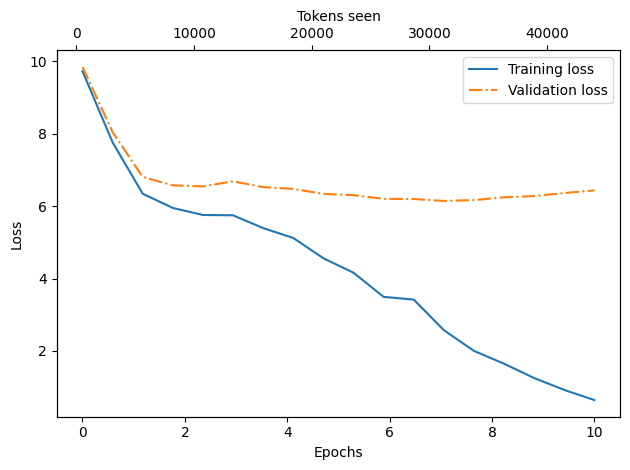

In [94]:
# Plot results
epochs_tensor = torch.linspace(0, OTHER_SETTINGS["num_epochs"], len(train_losses))
plot_losses(epochs_tensor, num_tokens_seen, train_losses, val_losses)
plt.savefig("loss.pdf")

# Save and load model
torch.save(model.state_dict(), "model.pth")
model = GPTModel(GPT_CONFIG)
model.load_state_dict(torch.load("model.pth", weights_only=True))



### Result Analysis
Notice that there is huge difference between Training Loss and Validation Loss, it's a clear sign of Overfitting. This is because:
* We are using a very very small dataset to train our model
* And we are training it for multiple iterations

In practice, the training of an LLM is done over a very large dataset for only one epoch.

Perplexity provides a measure of alignment between the probability distribution of predictions made by model vs the actual distribution of words from the dataset. Like here, 1.9 means at final epoch, the model was unclear among 2 words for the next word predictions, from the dataset.